In [ ]:
!pip install -q gradio

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
import gradio as gr
from glob import glob
from PIL import Image


In [ ]:
drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/Dataset"
IMG_HEIGHT = 256
IMG_WIDTH = 256
N_CHANNELS = 3          # use 1 if your SAR is single-channel
BATCH_SIZE = 16
SEED = 42


Mounted at /content/drive


In [ ]:
from glob import glob

def all_images(folder):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")
    paths = []
    for e in exts:
        paths.extend(glob(os.path.join(folder, e)))
    return sorted(paths)


In [ ]:
# train folders (adjust inner 'train' if needed after checking os.walk)
train_oil_dir = os.path.join(DATA_ROOT, "train", "train", "oilspill")
train_no_dir  = os.path.join(DATA_ROOT, "train", "train", "nospill")

# test folders
test_oil_dir = os.path.join(DATA_ROOT, "test", "test", "oilspill")
test_no_dir  = os.path.join(DATA_ROOT, "test", "test", "nospill")

train_oil = all_images(train_oil_dir)
train_no  = all_images(train_no_dir)

test_oil = all_images(test_oil_dir)
test_no  = all_images(test_no_dir)

train_img_paths = train_oil + train_no
train_labels = [1] * len(train_oil) + [0] * len(train_no)

test_img_paths = test_oil + test_no
test_labels = [1] * len(test_oil) + [0] * len(test_no)

print("Train oilspill:", len(train_oil))
print("Train nospill:", len(train_no))
print("Test oilspill:", len(test_oil))
print("Test nospill:", len(test_no))
print("Total train:", len(train_img_paths), "Total test:", len(test_img_paths))

if len(train_img_paths) == 0:
    raise ValueError("No training images found. Check DATA_ROOT and train folder names.")


Train oilspill: 99
Train nospill: 98
Test oilspill: 22
Test nospill: 27
Total train: 197 Total test: 49


In [ ]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
N_CHANNELS = 3
BATCH_SIZE = 16

def load_image_and_label(path, label):
    def _load(_path, _label):
        img = Image.open(_path.decode())
        if img.mode != "RGB":
            img = img.convert("RGB")
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))
        arr = np.array(img, dtype=np.float32) / 255.0
        return arr, np.float32(_label)
    img, lab = tf.numpy_function(
        _load, [path, label], [tf.float32, tf.float32]
    )
    img.set_shape([IMG_HEIGHT, IMG_WIDTH, N_CHANNELS])
    lab.set_shape([])
    return img, lab

def build_cls_dataset(img_paths, labels, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((img_paths, labels))
    ds = ds.map(load_image_and_label, num_parallel_calls=tf.data.AUTOTUNE)

    def augment(img, lab):
        if tf.random.uniform(()) > 0.5:
            img = tf.image.flip_left_right(img)
        if tf.random.uniform(()) > 0.5:
            img = tf.image.flip_up_down(img)
        return img, lab

    if shuffle:
        ds = ds.shuffle(buffer_size=1024, seed=SEED)
    ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_cls_dataset(train_img_paths, train_labels, shuffle=True)
test_ds  = build_cls_dataset(test_img_paths,  test_labels,  shuffle=False)

print(train_ds, test_ds)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))> <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


In [ ]:
def build_classifier(input_shape=(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="OilSpillClassifier")
    return model

model = build_classifier()
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.Precision(), keras.metrics.Recall()],
)
model.summary()


Model: "OilSpillClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,648,193 (128.36 MB)

 Trainable params: 33,648,193 (128.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)):
    inputs = keras.Input(shape=input_shape)

    # Encoder (downsampling path)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D(2)(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D(2)(c3)

    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D(2)(c4)

    # Bottleneck
    c5 = layers.Conv2D(512, 3, activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(512, 3, activation='relu', padding='same')(c5)

    # Decoder (upsampling path)
    u6 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(256, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(256, 3, activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(128, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(128, 3, activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(64, 3, activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(64, 3, activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(32, 3, activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(32, 3, activation='relu', padding='same')(c9)

    # Output layer
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c9)

    model = keras.Model(inputs, outputs, name='UNet_OilSpill')
    return model

In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )
MODEL_PATH = "/content/oilspill_classifier_best.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor="val_accuracy", mode="max",
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=8, mode="max",
        restore_best_weights=True
    ),
]

EPOCHS = 25

history = model.fit(
    train_ds,
    validation_data=test_ds,   # using your test folder as validation
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2,
)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

model = build_unet()
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        keras.metrics.BinaryAccuracy(name="pixel_accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)
model.summary()


Epoch 1/25

Epoch 1: val_accuracy improved from -inf to 0.55102, saving model to /content/oilspill_classifier_best.keras
13/13 - 60s - 5s/step - accuracy: 0.5330 - loss: 0.8252 - precision: 0.5455 - recall: 0.4242 - val_accuracy: 0.5510 - val_loss: 0.6776 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/25

Epoch 2: val_accuracy did not improve from 0.55102
13/13 - 25s - 2s/step - accuracy: 0.4975 - loss: 0.6878 - precision: 0.5000 - recall: 0.1919 - val_accuracy: 0.5510 - val_loss: 0.6936 - val_precision: 0.5000 - val_recall: 0.4091
Epoch 3/25

Epoch 3: val_accuracy improved from 0.55102 to 0.57143, saving model to /content/oilspill_classifier_best.keras
13/13 - 28s - 2s/step - accuracy: 0.5076 - loss: 0.6985 - precision: 0.5100 - recall: 0.5152 - val_accuracy: 0.5714 - val_loss: 0.6859 - val_precision: 0.5714 - val_recall: 0.1818
Epoch 4/25

Epoch 4: val_accuracy did not improve from 0.57143
13/13 - 25s - 2s/step - accuracy: 0.4315 - loss: 0.7006 - precision: 0.4381 - rec

Model: "UNet_OilSpill"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 128, 128,  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_9[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_6[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ conv2d_11[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    524,544 │ conv2d_12[0][0]   │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 7,760,097 (29.60 MB)

 Trainable params: 7,760,097 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
best_model = keras.models.load_model(MODEL_PATH)

test_loss, test_acc, test_prec, test_rec = best_model.evaluate(test_ds, verbose=2)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)
print("Precision:", test_prec, "Recall:", test_rec)


4/4 - 3s - 735ms/step - accuracy: 0.6939 - loss: 0.5907 - precision: 0.8182 - recall: 0.4091
Test loss: 0.5907444357872009
Test accuracy: 0.6938775777816772
Precision: 0.8181818127632141 Recall: 0.40909090638160706


Total images found in dataset: 247

🎲 Randomly selected image: /content/drive/MyDrive/Dataset/train/train/nospill/136992735_396875208282222_1813019295886707905_n.jpg

IMAGE ANALYSIS: 136992735_396875208282222_1813019295886707905_n.jpg

📐 IMAGE DIMENSIONS:
   Width: 1080 pixels
   Height: 1080 pixels
   Total pixels: 1,166,400

🎨 RGB STATISTICS:
   Red Channel:
      Mean: 134.33
      Std Dev: 63.95
      Min: 0
      Max: 244
      Median: 164.00
   Green Channel:
      Mean: 190.59
      Std Dev: 29.55
      Min: 0
      Max: 255
      Median: 198.00
   Blue Channel:
      Mean: 220.98
      Std Dev: 25.06
      Min: 19
      Max: 255
      Median: 226.00

⚫ GRAYSCALE STATISTICS:
   Mean intensity: 177.23
   Std deviation: 36.59
   Min intensity: 2
   Max intensity: 252
   Median intensity: 191.00
   Range: 250

📊 PERCENTILES (Grayscale):
   10th percentile: 121.00
   25th percentile: 151.00
   50th percentile: 191.00
   75th percentile: 203.00
   90th percentile: 213.00
   95th perc

/tmp/ipython-input-80061319.py:167: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_to_plot, labels=['R', 'G', 'B', 'Gray'],


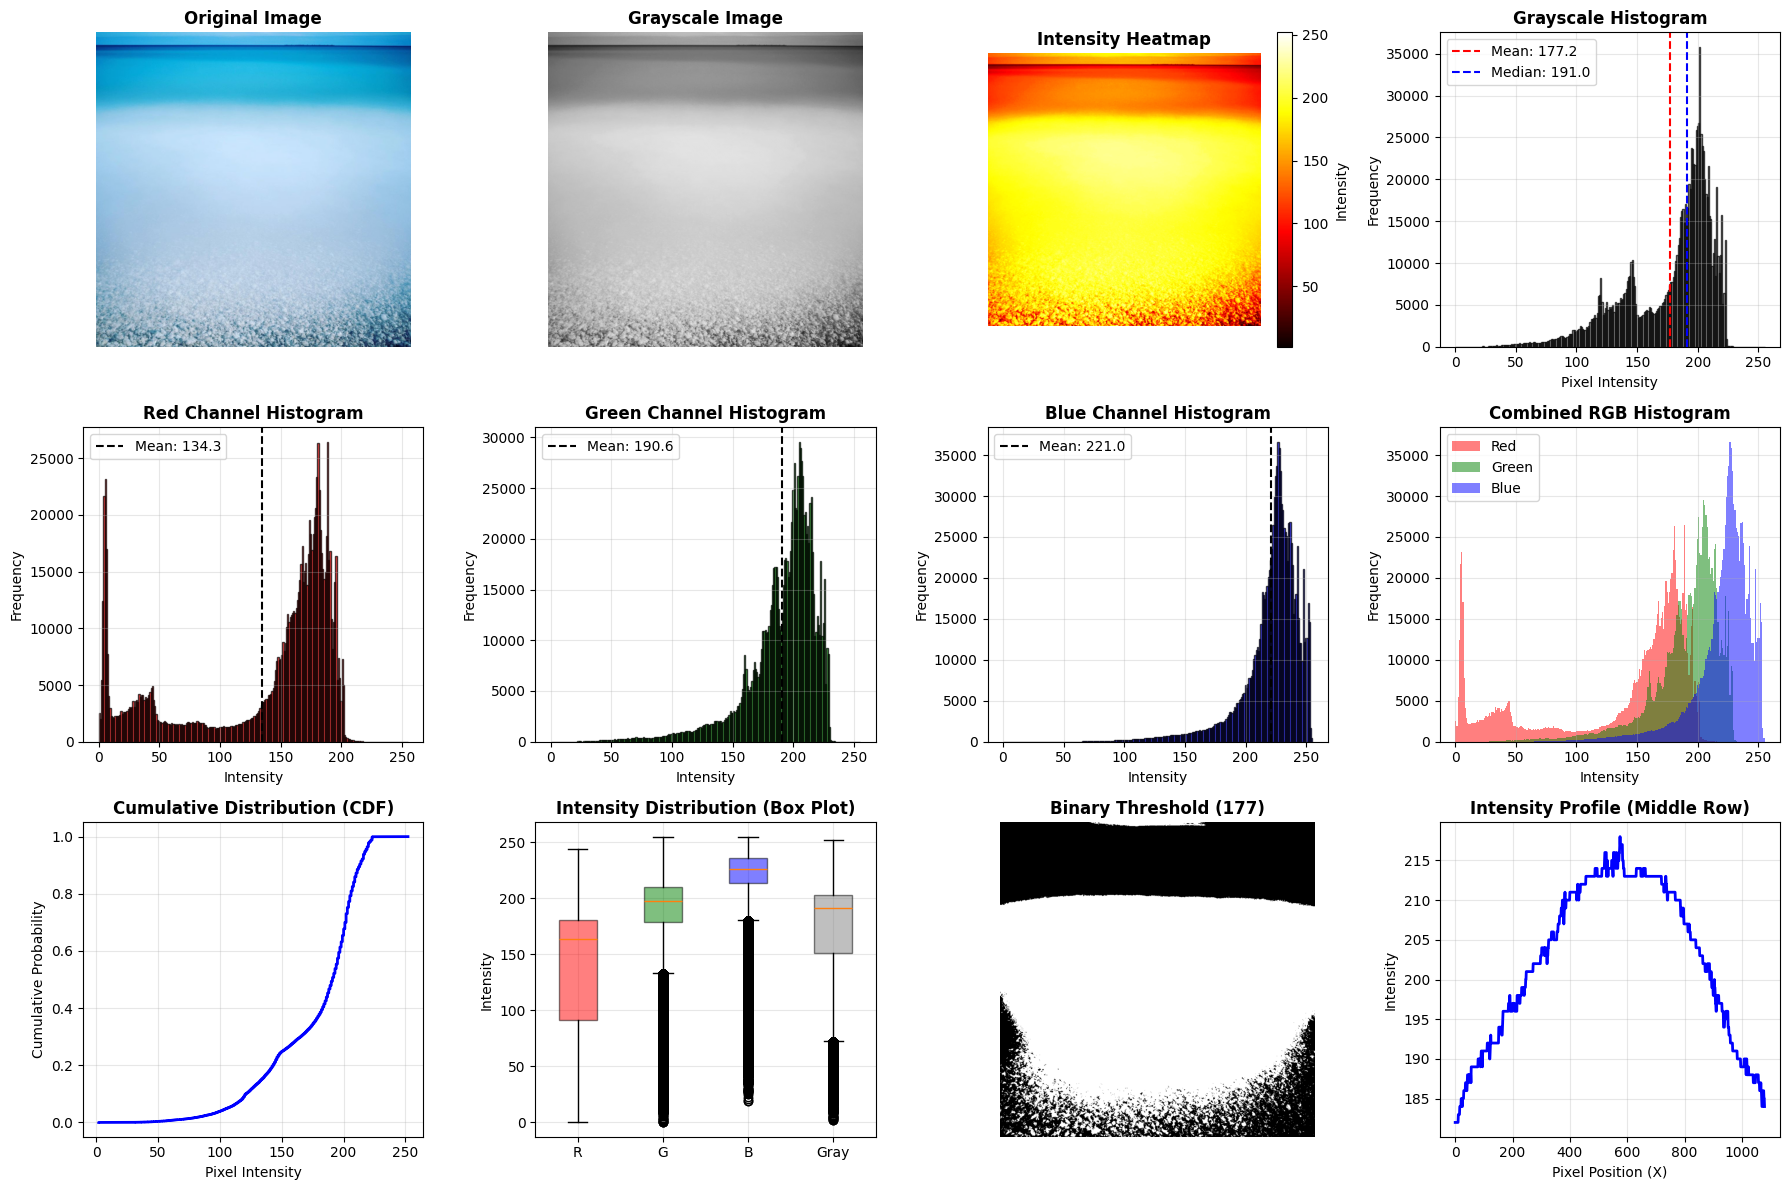


✅ ANALYSIS COMPLETE!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
from glob import glob

# ============================================
# COMPLETE PIXEL INTENSITY ANALYSIS CODE
# ============================================

def analyze_image_intensity(image_path):
    """
    Comprehensive pixel intensity analysis for an image
    Returns statistics, histograms, and visualizations
    """

    # Load image
    img = Image.open(image_path)

    # Convert to RGB if needed
    if img.mode != 'RGB':
        img = img.convert('RGB')

    # Convert to numpy array
    img_array = np.array(img, dtype=np.float32)

    # Get grayscale version
    gray_img = img.convert('L')
    gray_array = np.array(gray_img, dtype=np.float32)

    # ===== INTENSITY STATISTICS =====
    print("="*60)
    print(f"IMAGE ANALYSIS: {os.path.basename(image_path)}")
    print("="*60)

    # Image dimensions
    height, width = gray_array.shape
    print(f"\n📐 IMAGE DIMENSIONS:")
    print(f"   Width: {width} pixels")
    print(f"   Height: {height} pixels")
    print(f"   Total pixels: {width * height:,}")

    # RGB Statistics
    print(f"\n🎨 RGB STATISTICS:")
    for i, channel in enumerate(['Red', 'Green', 'Blue']):
        channel_data = img_array[:, :, i]
        print(f"   {channel} Channel:")
        print(f"      Mean: {np.mean(channel_data):.2f}")
        print(f"      Std Dev: {np.std(channel_data):.2f}")
        print(f"      Min: {np.min(channel_data):.0f}")
        print(f"      Max: {np.max(channel_data):.0f}")
        print(f"      Median: {np.median(channel_data):.2f}")

    # Grayscale Statistics
    print(f"\n⚫ GRAYSCALE STATISTICS:")
    print(f"   Mean intensity: {np.mean(gray_array):.2f}")
    print(f"   Std deviation: {np.std(gray_array):.2f}")
    print(f"   Min intensity: {np.min(gray_array):.0f}")
    print(f"   Max intensity: {np.max(gray_array):.0f}")
    print(f"   Median intensity: {np.median(gray_array):.2f}")
    print(f"   Range: {np.ptp(gray_array):.0f}")

    # Percentile values
    print(f"\n📊 PERCENTILES (Grayscale):")
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    for p in percentiles:
        val = np.percentile(gray_array, p)
        print(f"   {p}th percentile: {val:.2f}")

    # Intensity distribution
    unique_intensities = len(np.unique(gray_array))
    print(f"\n🔢 INTENSITY DISTRIBUTION:")
    print(f"   Unique intensity values: {unique_intensities}")

    # Dark/Medium/Bright pixel counts
    dark_pixels = np.sum(gray_array < 85)
    medium_pixels = np.sum((gray_array >= 85) & (gray_array < 170))
    bright_pixels = np.sum(gray_array >= 170)
    total = gray_array.size

    print(f"   Dark pixels (0-84): {dark_pixels:,} ({dark_pixels/total*100:.1f}%)")
    print(f"   Medium pixels (85-169): {medium_pixels:,} ({medium_pixels/total*100:.1f}%)")
    print(f"   Bright pixels (170-255): {bright_pixels:,} ({bright_pixels/total*100:.1f}%)")

    # ===== VISUALIZATIONS =====
    fig = plt.figure(figsize=(18, 12))

    # 1. Original Image
    plt.subplot(3, 4, 1)
    plt.imshow(img)
    plt.title('Original Image', fontsize=12, fontweight='bold')
    plt.axis('off')

    # 2. Grayscale Image
    plt.subplot(3, 4, 2)
    plt.imshow(gray_array, cmap='gray')
    plt.title('Grayscale Image', fontsize=12, fontweight='bold')
    plt.axis('off')

    # 3. Intensity Heatmap
    plt.subplot(3, 4, 3)
    plt.imshow(gray_array, cmap='hot')
    plt.colorbar(label='Intensity')
    plt.title('Intensity Heatmap', fontsize=12, fontweight='bold')
    plt.axis('off')

    # 4. Histogram - Grayscale
    plt.subplot(3, 4, 4)
    plt.hist(gray_array.flatten(), bins=256, range=(0, 255),
             color='gray', alpha=0.7, edgecolor='black')
    plt.axvline(np.mean(gray_array), color='red', linestyle='--',
                label=f'Mean: {np.mean(gray_array):.1f}')
    plt.axvline(np.median(gray_array), color='blue', linestyle='--',
                label=f'Median: {np.median(gray_array):.1f}')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.title('Grayscale Histogram', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 5-7. RGB Channel Histograms
    colors = ['red', 'green', 'blue']
    channel_names = ['Red', 'Green', 'Blue']

    for i, (color, name) in enumerate(zip(colors, channel_names)):
        plt.subplot(3, 4, 5 + i)
        channel_data = img_array[:, :, i].flatten()
        plt.hist(channel_data, bins=256, range=(0, 255),
                color=color, alpha=0.7, edgecolor='black')
        plt.axvline(np.mean(channel_data), color='black',
                   linestyle='--', label=f'Mean: {np.mean(channel_data):.1f}')
        plt.xlabel('Intensity')
        plt.ylabel('Frequency')
        plt.title(f'{name} Channel Histogram', fontsize=12, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)

    # 8. Combined RGB Histogram
    plt.subplot(3, 4, 8)
    for i, (color, name) in enumerate(zip(colors, channel_names)):
        channel_data = img_array[:, :, i].flatten()
        plt.hist(channel_data, bins=256, range=(0, 255),
                color=color, alpha=0.5, label=name)
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')
    plt.title('Combined RGB Histogram', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 9. Cumulative Distribution Function
    plt.subplot(3, 4, 9)
    sorted_intensities = np.sort(gray_array.flatten())
    cumulative = np.arange(1, len(sorted_intensities) + 1) / len(sorted_intensities)
    plt.plot(sorted_intensities, cumulative, color='blue', linewidth=2)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Cumulative Probability')
    plt.title('Cumulative Distribution (CDF)', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # 10. Intensity Box Plot
    plt.subplot(3, 4, 10)
    data_to_plot = [img_array[:, :, 0].flatten(),
                    img_array[:, :, 1].flatten(),
                    img_array[:, :, 2].flatten(),
                    gray_array.flatten()]
    box = plt.boxplot(data_to_plot, labels=['R', 'G', 'B', 'Gray'],
                      patch_artist=True)
    for patch, color in zip(box['boxes'], ['red', 'green', 'blue', 'gray']):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    plt.ylabel('Intensity')
    plt.title('Intensity Distribution (Box Plot)', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # 11. Thresholded Images
    plt.subplot(3, 4, 11)
    threshold = np.mean(gray_array)
    binary = (gray_array > threshold).astype(np.uint8) * 255
    plt.imshow(binary, cmap='gray')
    plt.title(f'Binary Threshold ({threshold:.0f})', fontsize=12, fontweight='bold')
    plt.axis('off')

    # 12. Intensity Profile (Middle Row)
    plt.subplot(3, 4, 12)
    mid_row = gray_array[height//2, :]
    plt.plot(mid_row, color='blue', linewidth=2)
    plt.xlabel('Pixel Position (X)')
    plt.ylabel('Intensity')
    plt.title('Intensity Profile (Middle Row)', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'mean': np.mean(gray_array),
        'std': np.std(gray_array),
        'min': np.min(gray_array),
        'max': np.max(gray_array),
        'median': np.median(gray_array),
        'shape': img_array.shape,
        'gray_array': gray_array,
        'rgb_array': img_array
    }

# ============================================
# ANALYZE RANDOM IMAGE FROM DATASET
# ============================================

# Define your dataset path (adjust to your oil spill dataset)
DATA_ROOT = "/content/drive/MyDrive/Dataset"

# Get all images from dataset
all_images = []
for folder in ['train/train/oilspill', 'train/train/nospill',
               'test/test/oilspill', 'test/test/nospill']:
    folder_path = os.path.join(DATA_ROOT, folder)
    if os.path.exists(folder_path):
        images = glob(os.path.join(folder_path, '*.*'))
        all_images.extend(images)

print(f"Total images found in dataset: {len(all_images)}")

# Select random image
if all_images:
    random_image = random.choice(all_images)
    print(f"\n🎲 Randomly selected image: {random_image}\n")

    # Analyze the image
    stats = analyze_image_intensity(random_image)

    print("\n" + "="*60)
    print("✅ ANALYSIS COMPLETE!")
    print("="*60)
else:
    print("❌ No images found in dataset. Please check DATA_ROOT path.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 894ms/step


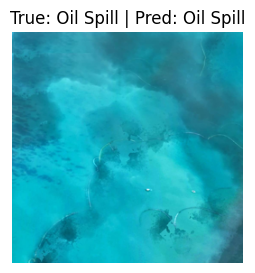

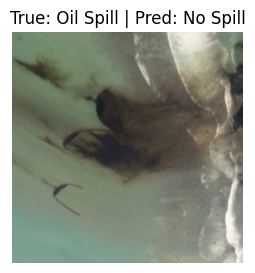

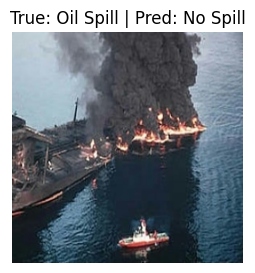

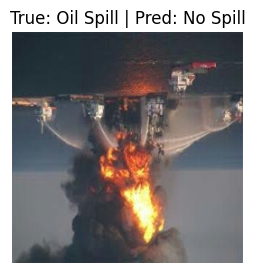

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step


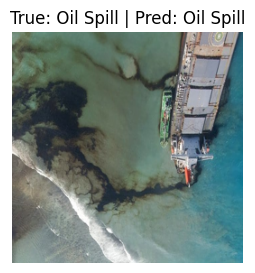

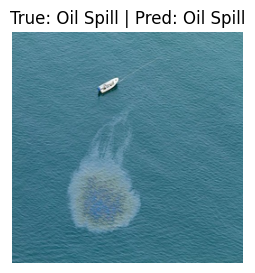

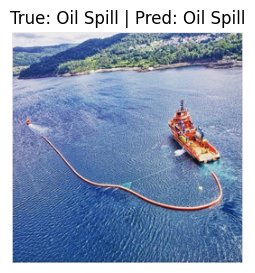

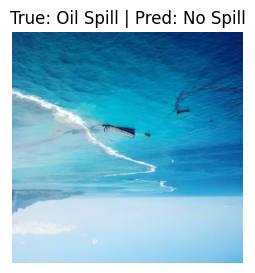

In [ ]:
import random

class_names = {0: "No Spill", 1: "Oil Spill"}

def show_random_predictions(dataset, num_batches=1):
    for imgs, labs in dataset.take(num_batches):
        preds = (best_model.predict(imgs) > 0.5).astype("int32").flatten()
        labs  = labs.numpy().astype("int32")
        for i in range(min(4, imgs.shape[0])):
            plt.figure(figsize=(3, 3))
            plt.imshow(imgs[i])
            plt.axis("off")
            plt.title(
                f"True: {class_names[int(labs[i])]} | Pred: {class_names[int(preds[i])]}"
            )
            plt.show()

show_random_predictions(test_ds, num_batches=2)
